# 📊 F1 Raw Data Profiling
**Mục tiêu:** Phân tích dữ liệu thô SAU khi crawl, TRƯỚC khi clean — để đưa ra chiến lược cleaning đúng.

### 7 Kỹ thuật áp dụng:
1. Data Consolidation & Unification
2. Data Profiling (Descriptive Stats)
3. Data Sanitization (Invalid values, whitespace)
4. Low Variance Filtering (99% threshold)
5. Missing Value Analysis & Visualization
6. Deduplication Check
7. Datetime Feature Detection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='darkgrid', palette='muted')

RAW_DIR = Path('../data/raw')
LOW_VARIANCE_THRESHOLD = 0.99   # Cột có >99% cùng giá trị → loại
HIGH_MISSING_THRESHOLD = 0.20   # Cột có >20% null → cân nhắc drop
print('Setup OK ✅')

Setup OK ✅


---
## 1️⃣ Data Consolidation & Unification
Gộp tất cả session-based files của từng endpoint, kiểm tra Type Matching và Schema Alignment.

In [2]:
def load_endpoint(endpoint: str) -> pd.DataFrame:
    """Load và gộp tất cả file CSV/Parquet của một endpoint."""
    ep_dir = RAW_DIR / endpoint
    if not ep_dir.exists():
        return pd.DataFrame()
    files = list(ep_dir.glob('**/*.csv')) + list(ep_dir.glob('**/*.parquet'))
    if not files:
        return pd.DataFrame()

    frames = []
    schema_issues = []
    ref_cols = None

    for f in files:
        df = pd.read_parquet(f) if f.suffix == '.parquet' else pd.read_csv(f, low_memory=False)
        if df.empty:
            continue

        if ref_cols is None:
            ref_cols = set(df.columns)
        else:
            extra = set(df.columns) - ref_cols
            missing = ref_cols - set(df.columns)
            if extra or missing:
                schema_issues.append({'file': f.name, 'extra_cols': list(extra), 'missing_cols': list(missing)})

        frames.append(df)

    if schema_issues:
        print(f'⚠️  Schema issues in [{endpoint}]:')
        display(pd.DataFrame(schema_issues))

    combined = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    combined['_source_endpoint'] = endpoint
    return combined


# Load tất cả endpoints tìm thấy trong data/raw/
ENDPOINTS = [d.name for d in RAW_DIR.iterdir() if d.is_dir()]
print(f'Found endpoints: {ENDPOINTS}')

dfs = {}
for ep in ENDPOINTS:
    df = load_endpoint(ep)
    if not df.empty:
        dfs[ep] = df
        print(f'  ✅ {ep}: {len(df):,} rows × {len(df.columns)} cols')
    else:
        print(f'  ⚫ {ep}: no data')

Found endpoints: ['car_data', 'drivers', 'intervals', 'laps', 'location', 'meetings', 'overtakes', 'pit', 'position', 'race_control', 'sessions', 'session_result', 'starting_grid', 'stints', 'team_radio', 'weather']
  ✅ car_data: 85,151,808 rows × 23 cols
  ✅ drivers: 3,717 rows × 13 cols
  ✅ intervals: 1,423,743 rows × 7 cols
  ✅ laps: 86,008 rows × 17 cols
  ✅ location: 43,062,384 rows × 13 cols
  ✅ meetings: 180 rows × 19 cols
  ✅ overtakes: 14,127 rows × 7 cols
  ✅ pit: 8,057 rows × 9 cols
  ✅ position: 116,928 rows × 6 cols
  ✅ race_control: 10,078 rows × 12 cols
  ✅ sessions: 180 rows × 16 cols
⚠️  Schema issues in [session_result]:


,file,extra_cols,missing_cols
0,9472.csv,[points],[]
1,9480.csv,[points],[]
2,9488.csv,[points],[]
3,9496.csv,[points],[]
4,9506.csv,[points],[]
...,...,...,...
64,11275.csv,[points],[]
65,11280.csv,[points],[]
66,11286.csv,[points],[]
67,11291.csv,[points],[]


  ✅ session_result: 2,784 rows × 12 cols
  ✅ starting_grid: 1,377 rows × 6 cols
  ✅ stints: 9,400 rows × 9 cols
  ✅ team_radio: 5,892 rows × 6 cols
  ✅ weather: 15,194 rows × 11 cols


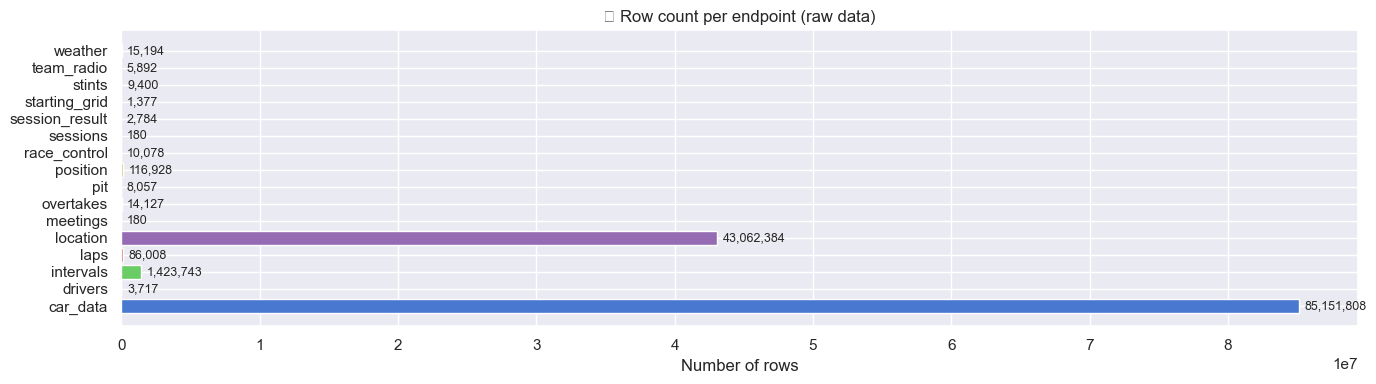

In [21]:
# Biểu đồ: số lượng dòng theo endpoint
sizes = {ep: len(df) for ep, df in dfs.items()}
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.barh(list(sizes.keys()), list(sizes.values()), color=sns.color_palette('muted', len(sizes)))
ax.bar_label(bars, labels=[f'{v:,}' for v in sizes.values()], padding=4, fontsize=9)
ax.set_xlabel('Number of rows')
ax.set_title('📦 Row count per endpoint (raw data)')
plt.tight_layout()
plt.show()

---
## 2️⃣ Data Profiling — Descriptive Statistics & Unique Values


In [22]:
for ep, df in dfs.items():
    if len(df) > 500000:
        df_display = df.sample(frac=0.1, random_state=42)
        print(f'\n{"="*70}')
        print(f'=== [{ep}] Shape: {len(df):,} rows × {len(df.columns)} cols (using 10% sample for analysis) ===')
        print(f'{"="*70}')
    else:
        df_display = df
        print(f'\n{"="*70}')
        print(f'=== [{ep}] Shape: {df.shape} ===')
        print(f'{"="*70}')

    print('\n--- Descriptive Statistics ---')
    display(df_display.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['count']))

    print('\n--- Unique Value Analysis ---')
    unique_counts = df_display.nunique()
    null_counts = df_display.isnull().sum()
    
    unique_info = pd.DataFrame({
        'dtype': df_display.dtypes,
        'nunique': unique_counts,
        'null_count': null_counts,
        'null_%': (null_counts / len(df_display) * 100).round(2),
        'sample_values': [df_display[c].dropna().iloc[:5].tolist() for c in df_display.columns]
    })
    
    unique_info['likely_type'] = unique_info.apply(
        lambda r: 'ID/Key' if r['nunique'] == len(df_display) else
                  'Categorical' if r['nunique'] < 30 else
                  'High-card text' if r['dtype'] == 'object' else 'Numeric', axis=1
    )
    
    display(unique_info.style.background_gradient(cmap='Oranges', subset=['null_%']))
    print('\n')


=== [car_data] Shape: 85,151,808 rows × 23 cols (using 10% sample for analysis) ===

--- Descriptive Statistics ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,8515181,nan,nan,nan,2025-03-04 23:56:11.721691648,2024-03-01 16:00:11.226000,2024-03-02 15:59:17.239000064,2025-03-16 04:39:48.991000064,2026-03-07 05:38:58.614000128,2026-03-08 05:27:54.538000,nan
SessionTime,8515181,nan,nan,nan,0 days 01:26:07.279454525,0 days 00:12:31.873000,0 days 00:53:33.403000,0 days 01:24:52.549000,0 days 01:59:11.777000,0 days 02:53:47.250000,0 days 00:40:22.444161169
DriverAhead,8515181,29,,1110831,nan,nan,nan,nan,nan,nan,nan
DistanceToDriverAhead,8164230.000000,nan,nan,nan,910.262377,0.000000,69.313688,207.608056,598.304443,65222.260000,2861.743437
Time,8515181,nan,nan,nan,0 days 00:01:38.000135676,0 days 00:00:00,0 days 00:00:29.418000,0 days 00:00:58.947000,0 days 00:01:30.220000,0 days 00:26:44.406000,0 days 00:02:17.126947997
RPM,8515181.000000,nan,nan,nan,8482.272161,0.000000,7592.160547,10228.666667,11013.000000,13630.000000,3773.402251
Speed,8515181.000000,nan,nan,nan,160.916264,0.000000,92.578570,171.392859,242.000000,343.000000,96.770775
nGear,8515181.000000,nan,nan,nan,4.061452,0.000000,2.000000,4.000000,6.000000,128.000000,2.782025
Throttle,8515181.000000,nan,nan,nan,59.181833,0.000000,1.485714,73.100006,100.000000,104.000000,43.320983
Brake,8515181,2,False,6255559,nan,nan,nan,nan,nan,nan,nan



--- Unique Value Analysis ---


,dtype,nunique,null_count,null_%,sample_values,likely_type
Date,datetime64[ns],223970,0,0.000000,"[Timestamp('2025-03-16 05:16:06.518000'), Timestamp('2024-03-02 16:29:20.486000'), Timestamp('2026-03-08 04:25:55.559000'), Timestamp('2026-03-08 04:18:38.799000'), Timestamp('2025-03-16 04:23:00.173000')]",Numeric
SessionTime,timedelta64[ns],222442,0,0.000000,"[Timedelta('0 days 02:08:43.899000'), Timedelta('0 days 02:25:38.055000'), Timedelta('0 days 01:24:48.936000'), Timedelta('0 days 01:17:32.176000'), Timedelta('0 days 01:15:37.554000')]",Numeric
DriverAhead,object,29,0,0.000000,"['81', '18', '1', '14', '31']",Categorical
DistanceToDriverAhead,float64,3031906,350951,4.120000,"[133.84222222222616, 521.4524999999998, 575.1205555555576, 157.29305555555658, 41.276111111114005]",Numeric
Time,timedelta64[ns],455861,0,0.000000,"[Timedelta('0 days 00:01:23.839000'), Timedelta('0 days 00:00:16.595000'), Timedelta('0 days 00:00:59.757000'), Timedelta('0 days 00:00:20.487000'), Timedelta('0 days 00:02:08.102000')]",Numeric
RPM,float64,1330150,0,0.000000,"[9029.0, 11444.0, 11113.2, 9957.8, 7418.0]",Numeric
Speed,float64,834858,0,0.000000,"[96.0, 210.0, 244.4, 130.95384615384614, 86.0]",Numeric
nGear,int64,105,0,0.000000,"[2, 5, 6, 3, 2]",Numeric
Throttle,float64,369693,0,0.000000,"[50.0, 100.0, 100.0, 73.49230769230769, 0.0]",Numeric
Brake,bool,2,0,0.000000,"[False, False, False, False, False]",Categorical





=== [drivers] Shape: (3717, 13) ===

--- Descriptive Statistics ---


...

,dtype,nunique,null_count,null_%,sample_values,likely_type
meeting_key,int64,50,0,0.000000,"[1229, 1229, 1229, 1229, 1229]",Numeric
session_key,int64,125,0,0.000000,"[9468, 9468, 9468, 9468, 9468]",Numeric
driver_number,int64,31,0,0.000000,"[55, 55, 31, 10, 16]",Numeric
date,object,5078,0,0.000000,"['2024-03-01T15:52:42.701000+00:00', '2024-03-01T16:02:22.270000+00:00', '2024-03-01T16:02:22.270000+00:00', '2024-03-01T16:02:57.444000+00:00', '2024-03-01T16:04:03.879000+00:00']",High-card text
recording_url,object,5892,0,0.000000,"['https://livetiming.formula1.com/static/2024/2024-03-02_Bahrain_Grand_Prix/2024-03-01_Qualifying/TeamRadio/CARSAI01_55_20240301_154816.mp3', 'https://livetiming.formula1.com/static/2024/2024-03-02_Bahrain_Grand_Prix/2024-03-01_Qualifying/TeamRadio/CARSAI01_55_20240301_160146.mp3', 'https://livetiming.formula1.com/static/2024/2024-03-02_Bahrain_Grand_Prix/2024-03-01_Qualifying/TeamRadio/ESTOCO01_31_20240301_160203.mp3', 'https://livetiming.formula1.com/static/2024/2024-03-02_Bahrain_Grand_Prix/2024-03-01_Qualifying/TeamRadio/PIEGAS01_10_20240301_160230.mp3', 'https://livetiming.formula1.com/static/2024/2024-03-02_Bahrain_Grand_Prix/2024-03-01_Qualifying/TeamRadio/CHALEC01_16_20240301_160356.mp3']",ID/Key
_source_endpoint,object,1,0,0.000000,"['team_radio', 'team_radio', 'team_radio', 'team_radio', 'team_radio']",Categorical





=== [weather] Shape: (15194, 11) ===

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,15194,15194,2024-03-01T15:46:51.334000+00:00,1,nan,nan,nan,nan,nan,nan,nan
session_key,15194.000000,nan,nan,nan,9943.702317,532.665672,9468.000000,9594.000000,9858.000000,9979.000000,11299.000000
air_temperature,15194.000000,nan,nan,nan,23.288818,4.988172,11.100000,19.600000,23.200000,27.300000,34.300000
track_temperature,15194.000000,nan,nan,nan,34.909734,9.314115,12.000000,28.200000,35.000000,42.700000,54.800000
humidity,15194.000000,nan,nan,nan,54.280644,17.037398,11.000000,42.000000,56.000000,66.000000,95.000000
pressure,15194.000000,nan,nan,nan,991.580032,46.818704,780.300000,989.200000,1009.000000,1016.400000,1031.000000
wind_direction,15194.000000,nan,nan,nan,180.908451,102.127490,0.000000,106.000000,186.000000,265.000000,360.000000
meeting_key,15194.000000,nan,nan,nan,1257.083520,16.513375,1229.000000,1243.000000,1257.000000,1271.000000,1286.000000
wind_speed,15194.000000,nan,nan,nan,1.823443,1.059949,0.000000,1.000000,1.600000,2.400000,7.300000
rainfall,15194.000000,nan,nan,nan,0.050480,0.218941,0.000000,0.000000,0.000000,0.000000,1.000000



--- Unique Value Analysis ---


,dtype,nunique,null_count,null_%,sample_values,likely_type
date,object,15194,0,0.000000,"['2024-03-01T15:46:51.334000+00:00', '2024-03-01T15:47:51.333000+00:00', '2024-03-01T15:48:51.320000+00:00', '2024-03-01T15:49:51.318000+00:00', '2024-03-01T15:50:51.334000+00:00']",ID/Key
session_key,int64,138,0,0.000000,"[9468, 9468, 9468, 9468, 9468]",Numeric
air_temperature,float64,232,0,0.000000,"[18.2, 18.1, 18.1, 18.1, 18.1]",Numeric
track_temperature,float64,416,0,0.000000,"[22.2, 22.2, 22.2, 22.2, 22.2]",Numeric
humidity,float64,446,0,0.000000,"[48.0, 48.0, 48.0, 48.0, 48.0]",Numeric
pressure,float64,582,0,0.000000,"[1018.8, 1018.8, 1018.8, 1018.8, 1018.8]",Numeric
wind_direction,int64,361,0,0.000000,"[53, 51, 57, 48, 45]",Numeric
meeting_key,int64,54,0,0.000000,"[1229, 1229, 1229, 1229, 1229]",Numeric
wind_speed,float64,70,0,0.000000,"[2.7, 2.9, 2.1, 2.4, 2.3]",Numeric
rainfall,int64,2,0,0.000000,"[0, 0, 0, 0, 0]",Categorical


---
## 3️⃣ Data Sanitization
### 3a. Giá trị phi lý (giá trị âm trong cột số)
### 3b. Whitespace detection

In [23]:
if ENDPOINT_TO_PROFILE in dfs:
    df = dfs[ENDPOINT_TO_PROFILE].copy()
    numeric_cols = df.select_dtypes(include='number').columns

    # 3a. Negative values
    neg_report = []
    for col in numeric_cols:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            neg_report.append({'column': col, 'negative_count': n_neg,
                                'pct': round(n_neg / len(df) * 100, 2),
                                'min_value': df[col].min()})

    if neg_report:
        print('⚠️  Negative values found:')
        display(pd.DataFrame(neg_report))
    else:
        print('✅ No negative values in numeric columns')

    # 3b. Whitespace-only strings
    ws_report = []
    for col in df.select_dtypes(include='object').columns:
        n_ws = df[col].astype(str).str.strip().eq('').sum()
        if n_ws > 0:
            ws_report.append({'column': col, 'blank_count': n_ws,
                               'pct': round(n_ws / len(df) * 100, 2)})

    if ws_report:
        print('\n⚠️  Whitespace/blank strings found:')
        display(pd.DataFrame(ws_report))
    else:
        print('✅ No whitespace-only strings')

✅ No negative values in numeric columns
✅ No whitespace-only strings


---
## 4️⃣ Low Variance Filtering (≥99% same value → useless column)

In [24]:
if ENDPOINT_TO_PROFILE in dfs:
    df = dfs[ENDPOINT_TO_PROFILE].copy()

    lv_report = []
    for col in df.columns:
        if col == '_source_endpoint':
            continue
        top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        top_val = df[col].value_counts(dropna=False).index[0]
        if top_freq >= LOW_VARIANCE_THRESHOLD:
            lv_report.append({'column': col, 'dominant_value': top_val,
                               'dominance_%': round(top_freq * 100, 2)})

    if lv_report:
        print(f'⚠️  Low-variance columns (≥{LOW_VARIANCE_THRESHOLD*100:.0f}% same value) → candidate for DROP:')
        display(pd.DataFrame(lv_report).style.background_gradient(cmap='Reds', subset=['dominance_%']))
    else:
        print('✅ No low-variance columns found')

✅ No low-variance columns found


---
## 5️⃣ Missing Value Analysis & Visualization

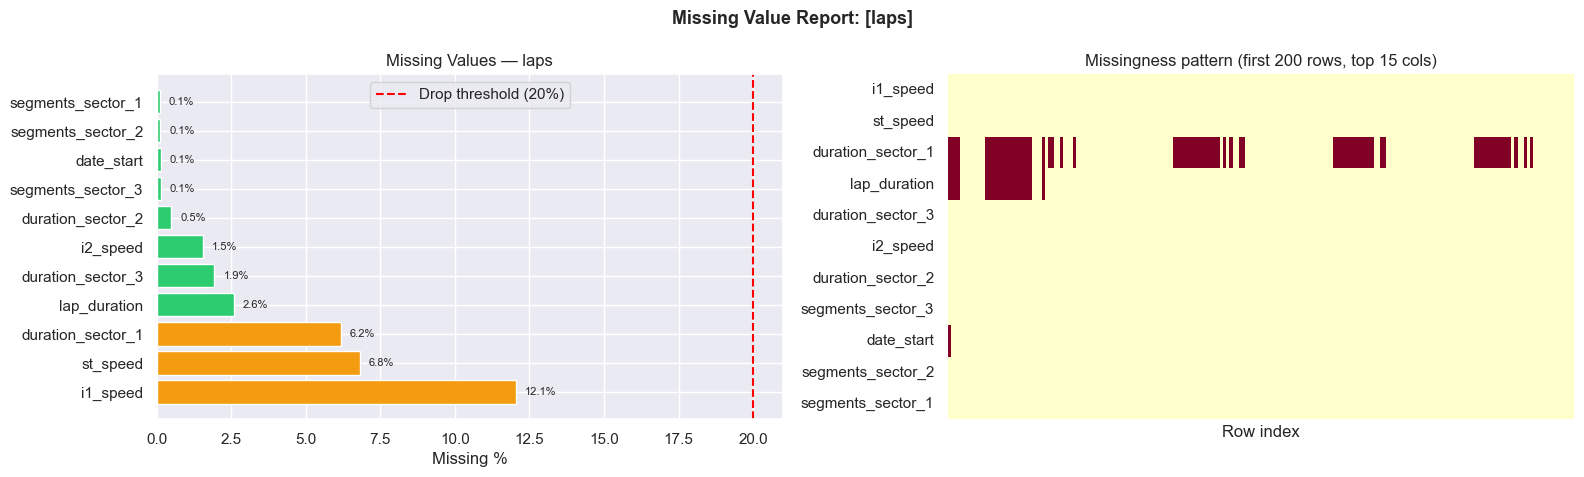

In [25]:
def plot_missing(df: pd.DataFrame, title: str = '', threshold: float = 0.0):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > threshold]
    if miss.empty:
        print(f'✅ No missing values above {threshold}% threshold')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(miss) * 0.35 + 1)))

    # Bar chart
    colors = ['#e74c3c' if v > HIGH_MISSING_THRESHOLD*100 else '#f39c12' if v > 5 else '#2ecc71'
              for v in miss.values]
    axes[0].barh(miss.index, miss.values, color=colors)
    axes[0].axvline(HIGH_MISSING_THRESHOLD * 100, color='red', linestyle='--', label=f'Drop threshold ({HIGH_MISSING_THRESHOLD*100:.0f}%)')
    axes[0].set_xlabel('Missing %')
    axes[0].set_title(f'Missing Values — {title}')
    axes[0].legend()
    for i, v in enumerate(miss.values):
        axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

    # Heatmap (top 15 cols max)
    top_cols = miss.head(15).index.tolist()
    sample = df[top_cols].head(200).isnull()
    sns.heatmap(sample.T, cmap='YlOrRd', cbar=False, ax=axes[1],
                xticklabels=False, yticklabels=True)
    axes[1].set_title('Missingness pattern (first 200 rows, top 15 cols)')
    axes[1].set_xlabel('Row index')

    plt.suptitle(f'Missing Value Report: [{title}]', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Drop recommendations
    to_drop = miss[miss > HIGH_MISSING_THRESHOLD * 100]
    if not to_drop.empty:
        print(f'\n🔴 Columns to consider DROPPING (>{HIGH_MISSING_THRESHOLD*100:.0f}% missing):')
        display(to_drop.reset_index().rename(columns={'index':'column', 0:'missing_%'}))


if ENDPOINT_TO_PROFILE in dfs:
    plot_missing(dfs[ENDPOINT_TO_PROFILE], title=ENDPOINT_TO_PROFILE, threshold=0)

In [26]:
# Missing overview cho TẤT CẢ endpoints
miss_summary = []
for ep, df in dfs.items():
    miss_pct = df.isnull().mean() * 100
    miss_summary.append({'endpoint': ep, 'rows': len(df),
                          'cols_total': len(df.columns),
                          'cols_any_null': (miss_pct > 0).sum(),
                          'cols_drop_candidate': (miss_pct > HIGH_MISSING_THRESHOLD*100).sum(),
                          'overall_null_%': round(df.isnull().values.mean() * 100, 2)})

miss_df = pd.DataFrame(miss_summary)
print('=== Missing Value Summary (All Endpoints) ===')
display(miss_df.style.background_gradient(cmap='Reds', subset=['overall_null_%', 'cols_drop_candidate']))

=== Missing Value Summary (All Endpoints) ===


,endpoint,rows,cols_total,cols_any_null,cols_drop_candidate,overall_null_%
0,car_data,85151808,23,2,0,0.180000
1,drivers,3717,13,2,1,5.410000
2,intervals,1423743,7,2,0,0.250000
3,laps,86008,17,11,0,1.890000
4,location,43062384,13,0,0,0.000000
5,meetings,180,19,0,0,0.000000
6,overtakes,14127,7,0,0,0.000000
7,pit,8057,9,3,1,14.010000
8,position,116928,6,0,0,0.000000
9,race_control,10078,12,6,6,31.760000


---
## 6️⃣ Deduplication Check

In [1]:
KEY_MAP = {
    'sessions':       ['session_key'],
    'drivers':        ['session_key', 'driver_number'],
    'laps':           ['session_key', 'driver_number', 'lap_number'],
    'stints':         ['session_key', 'driver_number', 'stint_number'],
    'weather':        ['session_key', 'date'],
    'intervals':      ['session_key', 'driver_number', 'date'],
    'starting_grid':  ['session_key', 'driver_number'],
    'session_result': ['session_key', 'driver_number'],
    'meetings':       ['meeting_key'],
}

dup_results = []
for ep, df in dfs.items():
    keys = [k for k in KEY_MAP.get(ep, []) if k in df.columns]
    # Full row duplicates
    full_dups = df.duplicated().sum()
    # Key duplicates
    key_dups = df.duplicated(subset=keys).sum() if keys else None
    dup_results.append({'endpoint': ep, 'total_rows': len(df),
                         'full_row_dups': full_dups,
                         'full_dup_%': round(full_dups/len(df)*100, 2),
                         'key_cols': str(keys),
                         'key_dups': key_dups})

dup_df = pd.DataFrame(dup_results)
print('=== Deduplication Report ===')
display(dup_df.style.background_gradient(cmap='Oranges', subset=['full_dup_%']))

NameError: name 'dfs' is not defined

---
## 7️⃣ Datetime Feature Detection & Transformation Check

In [ ]:
import re

DATE_PATTERNS = re.compile(r'date|time|start|end|created|updated', re.IGNORECASE)

dt_report = []
for ep, df in dfs.items():
    for col in df.select_dtypes(include='object').columns:
        if DATE_PATTERNS.search(col):
            sample = df[col].dropna().head(3).tolist()
            # Try parsing
            try:
                parsed = pd.to_datetime(df[col].dropna().head(100), errors='coerce')
                parse_rate = parsed.notna().mean() * 100
            except Exception:
                parse_rate = 0
            dt_report.append({'endpoint': ep, 'column': col,
                               'current_dtype': str(df[col].dtype),
                               'parse_success_%': round(parse_rate, 1),
                               'sample': str(sample[:2]),
                               'action': '✅ Convert to datetime' if parse_rate > 80 else '⚠️ Check format'})

if dt_report:
    print('=== Datetime Column Detection ===')
    display(pd.DataFrame(dt_report).style.applymap(
        lambda v: 'background-color: #d4edda' if '✅' in str(v) else
                  'background-color: #fff3cd' if '⚠️' in str(v) else '',
        subset=['action']
    ))
else:
    print('No datetime-like columns detected in object columns')

# Insight cuối EDA Raw và chiến lược cleaning đề xuất

## 1. Kết luận tổng quan từ EDA raw

EDA raw cho thấy dữ liệu đã được crawl khá rộng và có đủ nhiều endpoint để xây dựng pipeline dự đoán F1, nhưng dữ liệu thô chưa thể coi là ML-ready. Audit tự động ghi nhận **4 lỗi mức error** và **15 cảnh báo mức warning**. Các lỗi nghiêm trọng nhất không nằm ở việc thiếu file, mà nằm ở ba nhóm rủi ro chính: **domain value sai**, **schema không ổn định theo endpoint**, và **nguy cơ join sai grain/timestamp gây row explosion hoặc leakage**.

Vì vậy, bước tiếp theo không nên là đưa raw data trực tiếp vào feature engineering. Flow đúng là: raw profiling -> chuẩn hóa schema -> clean domain/value -> kiểm tra key/duplicate -> aggregate theo grain mục tiêu -> join có kiểm soát -> validation -> mới handoff sang feature engineering/ML.

## 2. Quy mô dữ liệu và ý nghĩa đối với pipeline

| Endpoint | Files | Rows | Size MB | Schemas | Nhận định |
|---|---:|---:|---:|---:|---|
| `car_data` | 144 | 85,151,808 | 4,560.94 | 1 | Endpoint lớn nhất, là telemetry tần suất cao; không nên join trực tiếp vào bảng lap/session nếu chưa aggregate. |
| `location` | 144 | 43,062,384 | 535.61 | 1 | Cũng là dữ liệu tần suất cao; nên dùng cho feature không gian/tốc độ sau khi aggregate, không dùng exact timestamp join bừa bãi. |
| `intervals` | 69 | 1,423,743 | 85.08 | 18 | Có schema drift mạnh; cần chuẩn hóa schema trước khi clean/join. |
| `position` | 138 | 116,928 | 5.80 | 6 | Dữ liệu vị trí có nhiều schema; cần xác định rõ dùng làm feature in-race hay dùng để suy luận kết quả. |
| `laps` | 137 | 86,008 | 20.96 | 1 | Endpoint lap-level ổn định về schema nhưng có lỗi domain ở `lap_duration`. Đây là nguồn rất quan trọng cho feature pace. |
| `weather` | 138 | 15,194 | 1.17 | 89 | Schema drift nặng nhất; dù ít dòng, đây là endpoint cần chuẩn hóa cẩn thận vì weather ảnh hưởng lớn tới race context. |
| `pit` | 134 | 8,057 | 0.50 | 39 | Schema drift cao; nên chuẩn hóa trước khi tạo feature pit strategy. |
| `drivers` | 180 | 3,717 | 0.88 | 1 | Phù hợp làm bảng driver-session base. |
| `session_result` | 138 | 2,784 | 0.21 | 2 | Có thể dùng để tạo target/result nhưng phải tách rõ label và feature. |
| `starting_grid` | 68 | 1,377 | 0.07 | 1 | Có giá trị cho pre-race model nếu grid đã biết tại thời điểm dự đoán. |

**Insight chính:** dữ liệu không nằm trên cùng một grain. `sessions`, `meetings` là session/meeting-level; `drivers`, `session_result`, `starting_grid` là driver-session-level; `laps`, `stints`, `pit` là lap/stint/event-level; `car_data`, `location`, `weather`, `intervals`, `position` có yếu tố thời gian và có thể là event/sub-second/time-series. Nếu join tất cả vào một bảng mà không khai báo grain trước, pipeline rất dễ tạo duplicate, row explosion hoặc feature nhìn thấy tương lai.

## 3. Insight về schema drift

Các endpoint có schema không ổn định:

| Endpoint | Số schema quan sát được | Số file bị cảnh báo | Rủi ro | Chiến lược clean |
|---|---:|---:|---|---|
| `weather` | 89 | 131 files | Rất cao: cùng endpoint nhưng nhiều biến thể cột, dễ làm mất cột khi concat hoặc sinh nhiều null. | Tạo canonical schema cho weather; thêm cột thiếu bằng `NaN`; ép kiểu numeric/datetime; chỉ giữ cột có ý nghĩa ổn định như temperature, humidity, pressure, rainfall, wind speed/direction nếu tồn tại. |
| `pit` | 39 | 124 files | Cao: pit event có thể khác cột theo session/year. | Chuẩn hóa tên cột pit event; parse thời gian pit; giữ key `session_key`, `driver_number`, lap/time nếu có; không drop file chỉ vì thiếu cột phụ. |
| `intervals` | 18 | 50 files | Trung bình-cao: interval time-series dễ sai khi parse cột `date`/gap. | Chuẩn hóa cột thời gian, gap/interval; convert interval string sang seconds nếu cần; validate key trước join. |
| `position` | 6 | 84 files | Trung bình: vị trí có thể dùng để suy luận current/final position, dễ leakage. | Chuẩn hóa `date`, `position`, `driver_number`; tách rõ feature in-race và label/result. |
| `session_result` | 2 | 69 files | Thấp-trung bình nhưng quan trọng vì liên quan target. | Chuẩn hóa result columns; chỉ dùng để tạo label/result; không đưa outcome columns vào feature set. |

**Quyết định:** schema drift phải được xử lý trước domain cleaning. Nếu chưa chuẩn hóa schema, các bước kiểm tra missing/domain có thể bị sai vì cùng một ý nghĩa nhưng bị tách thành nhiều tên cột hoặc bị thiếu theo file.

## 4. Insight về lỗi domain/value

| Severity | Endpoint | Column | Sample rows | Invalid rows | Invalid pct | Ý nghĩa | Chiến lược clean đề xuất |
|---|---|---|---:|---:|---:|---|---|
| error | `laps` | `lap_duration` | 86,008 | 1,150 | 1.34% | Lap duration ngoài [30, 600] giây. Đây là lỗi nghiêm trọng vì lap pace là feature lõi. | Không impute đại trà. Với lap duration < 30 hoặc > 600, set invalid thành `NaN` hoặc drop khỏi feature lap pace. Nếu lap thuộc safety car/red flag/out lap/in lap thì có thể giữ row nhưng đánh flag `is_abnormal_lap`. |
| error | `weather` | `pressure` | 15,194 | 480 | 3.16% | Áp suất ngoài [800, 1100], tỷ lệ cao nhất trong các lỗi domain. Có thể do đơn vị, sensor/API issue hoặc parse sai. | Kiểm tra phân phối pressure theo session. Giá trị ngoài range nên set `NaN`, không clamp mù vì pressure có ý nghĩa vật lý. Sau đó impute theo median của cùng session hoặc cùng meeting nếu tỷ lệ thiếu thấp. |
| warning | `car_data` | `Throttle` | 250,000 | 480 | 0.19% | Throttle ngoài [0, 100]. Tỷ lệ thấp nhưng trên endpoint rất lớn nên số dòng thực tế có thể đáng kể. | Nếu lệch nhẹ do sensor noise, clamp về [0,100]; nếu giá trị âm/lớn bất thường, set `NaN`. Khi aggregate telemetry, tính thêm tỷ lệ invalid throttle theo driver-session để audit. |
| warning | `laps` | `duration_sector_1` | 86,008 | 1 | ~0.00% | Chỉ 1 dòng ngoài [5, 120], không đáng kể. | Set `NaN` hoặc drop đúng cell; không drop cả session. |
| warning | `race_control` | `lap_number` | 10,078 | 21 | 0.21% | Lap number ngoài [1, 200]. Có thể là message pre/post race hoặc parsing issue. | Không dùng trực tiếp để join lap nếu ngoài range; giữ message text nhưng set `lap_number_clean = NaN` cho dòng invalid. |

**Quyết định:** lỗi domain ở `laps.lap_duration` và `weather.pressure` là blocking issue cho ML readiness. Sau cleaning phải chạy validation lại và kỳ vọng error-level domain issues giảm về 0 hoặc được giải thích bằng flag/caveat rõ ràng.

## 5. Insight về duplicate và key uniqueness

| Endpoint | Key kiểm tra | Sample rows | Full-row duplicates | Key duplicates | Nhận định | Chiến lược clean |
|---|---:|---:|---:|---|---|---|
| `car_data` | `session_key + driver_number + Date` | 250,000 | 0 | 264 | Không trùng nguyên dòng nhưng trùng key thời gian. Có thể do telemetry ghi nhiều record cùng timestamp hoặc precision thấp. | Không dedupe bằng full row. Trước khi aggregate, sort theo timestamp; nếu cùng key thì lấy mean/last theo nhóm hoặc thêm tie-breaker nếu có. Không join exact timestamp vào bảng lap/session. |
| `meetings` | `meeting_key` | 180 | 0 | 108 | `meeting_key` không unique trong raw sample, có thể do cùng meeting xuất hiện nhiều session/year file hoặc duplicate crawl. | Dedupe meetings theo canonical fields như `meeting_key`, `year`, `country`, `circuit_key`; nếu còn nhiều dòng, giữ bản đầy đủ nhất hoặc latest crawl. |
| `laps` | `session_key + driver_number + lap_number` | 86,008 | 0 | 0 | Key lap-level ổn định. | Có thể dùng làm backbone cho lap-level dataset sau khi clean domain. |
| `drivers` | `session_key + driver_number` | 3,717 | 0 | 0 | Key driver-session ổn định. | Có thể dùng làm backbone cho driver-session base. |
| `weather` | `session_key + date` | 15,194 | 0 | 0 | Key time-series ổn định sau schema clean. | Join bằng `merge_asof` hoặc aggregate theo session/lap window, không exact join nếu target grain khác. |

**Quyết định:** duplicate check cho thấy không nên dùng `drop_duplicates()` một cách chung chung. Mỗi endpoint cần dedupe theo grain của chính nó. Đặc biệt, `car_data` có duplicate key theo timestamp nhưng không có full-row duplicate, nên drop full-row không giải quyết được rủi ro join.

## 6. Insight về join và grain

Audit đưa ra 2 lỗi mức error liên quan join pipeline:

1. Không được join telemetry/weather/intervals/position bằng exact timestamp.
2. Trước mỗi join phải assert uniqueness của right-side key hoặc đo row growth để tránh many-to-many row explosion.

Chiến lược grain nên tách thành 2 artifact rõ ràng:

| Artifact | Grain | Backbone | Dùng cho |
|---|---|---|---|
| `driver_session_base` | `session_key + driver_number` | `drivers` hoặc result/grid/session tables | Pre-race hoặc session-level prediction. |
| `master_dataset` | `session_key + driver_number + lap_number` | `laps` | In-race/lap-level prediction hoặc dynamic win probability. |

Quy tắc join đề xuất:

- Với driver-session model: aggregate mọi dữ liệu thấp hơn grain lên driver-session trước khi join. Ví dụ: average lap pace, best lap, stint count, pit count, weather summary, grid position.
- Với lap-level model: dùng `laps` làm backbone, sau đó join weather/position/intervals bằng `merge_asof` theo `session_key`, `driver_number` nếu có, và timestamp/lap boundary với tolerance rõ ràng.
- Với telemetry `car_data` và `location`: không join raw 85M/43M rows vào bảng chính. Trước tiên aggregate theo lap hoặc driver-session: mean speed, max speed, throttle/brake ratio, DRS usage, distance coverage, invalid sensor rate.
- Sau mỗi join phải log `rows_before`, `rows_after`, `row_growth_ratio`, `duplicate_key_after_join`. Nếu row growth > 1.0 mà không có lý do rõ ràng thì block pipeline.

## 7. Insight về leakage

Audit cảnh báo các cột có thể gây leakage trong processed data:

| Dataset | Cột bị cảnh báo | Rủi ro |
|---|---|---|
| `driver_session_base` | `grid_position`, `final_position`, `target_win`, `target_podium`, `target_top10` | `final_position` và target là outcome. `grid_position` chỉ hợp lệ nếu bài toán dự đoán sau qualifying/trước race. |
| `master_dataset` | `current_position`, `position_gain_lap`, `final_position`, `target_win`, `target_podium`, `target_top10` | `final_position` và target không được dùng làm feature. `current_position`/`position_gain_lap` chỉ hợp lệ cho in-race model nếu timestamp không nhìn trước. |

Chiến lược chống leakage:

- Tạo danh sách `label_columns = [target_win, target_podium, target_top10, final_position]` và luôn exclude khỏi feature matrix.
- Tạo metadata `available_at` cho từng feature: `pre_season`, `pre_race`, `race_start`, `in_race_lap_t`, `post_race`.
- Nếu bài toán là pre-race win probability, không dùng `current_position`, `position_gain_lap`, `final_position`, target columns, hoặc bất kỳ thống kê nào cần dữ liệu sau race start.
- Nếu bài toán là in-race win probability tại lap t, chỉ dùng feature có timestamp <= thời điểm lap t. Các rolling feature phải shift trước khi tính target để không dùng thông tin của chính lap hiện tại/tương lai nếu không được phép.
- `grid_position` nên được đánh dấu conditional: được dùng cho pre-race model sau khi starting grid đã công bố, không dùng cho model dự đoán trước qualifying.

## 8. Chiến lược cleaning chi tiết theo endpoint

### `laps`

- Chuẩn hóa kiểu dữ liệu: `session_key`, `driver_number`, `lap_number` là key; duration columns là numeric seconds.
- Với `lap_duration` ngoài [30, 600]: set invalid thành `NaN` hoặc loại khỏi pace feature; không impute bằng global mean vì sẽ làm méo phân phối tốc độ.
- Tạo flag `is_invalid_lap_duration` để giữ dấu vết cleaning.
- Với sector duration invalid rất hiếm: set cell invalid thành `NaN`.
- Validate lại uniqueness của `session_key + driver_number + lap_number` sau cleaning.

### `weather`

- Xử lý schema drift trước: canonicalize column names, thêm cột thiếu bằng `NaN`.
- Parse `date` thành datetime timezone-consistent.
- Với `pressure` ngoài [800, 1100]: set `NaN`, tạo flag `is_invalid_pressure`.
- Impute pressure theo median của `session_key`; nếu session thiếu toàn bộ thì fallback theo `meeting_key` hoặc global median theo season.
- Không dùng forward-fill across session vì sẽ kéo weather của race này sang race khác.
- Khi join vào lap/session, dùng aggregate/asof có tolerance, không exact timestamp.

### `car_data`

- Không load/join toàn bộ raw vào master nếu không cần; endpoint có 85,151,808 rows và 4,560.94 MB.
- Với `Throttle` ngoài [0,100]: nếu chỉ vượt nhẹ thì clamp; nếu cực trị bất thường thì set `NaN`.
- Xử lý duplicate key `session_key + driver_number + Date`: group theo key và aggregate numeric bằng mean/last tùy feature.
- Tạo feature sau aggregate: average throttle, brake ratio, max speed, DRS rate, invalid throttle rate.
- Lưu telemetry aggregate riêng để tránh pipeline chính bị nặng.

### `location`

- Vì có 43,062,384 rows, chỉ dùng sau khi aggregate.
- Chuẩn hóa timestamp và numeric coordinates.
- Không join raw location vào lap/session bằng exact timestamp.
- Feature gợi ý: distance coverage per lap, average speed proxy, track position consistency nếu map được lap window.

### `intervals` và `position`

- Chuẩn hóa schema drift trước khi parse.
- Parse `date` thành datetime; convert gap/interval sang seconds nếu cần.
- Với `position`, tách rõ `current_position` dùng cho in-race và `final_position` dùng làm outcome.
- Khi aggregate lên driver-session, chỉ dùng thông tin hợp lệ tại prediction time.

### `pit` và `stints`

- Với `pit`, schema drift cao nên cần canonical schema; không drop file chỉ vì thiếu cột phụ.
- Feature session-level: pit stop count, first pit lap, average pit duration, total pit time.
- Feature lap-level: pit event on current/previous lap, tyre age, compound, stint number.
- Với `stints`, validate `stint_number` theo `session_key + driver_number`, kiểm tra overlap lap ranges nếu có start/end lap.

### `meetings`, `sessions`, `drivers`, `starting_grid`, `session_result`

- `meetings`: dedupe `meeting_key` bằng canonical metadata; kiểm tra vì có 108 key duplicates.
- `sessions`: `session_key` không duplicate, có thể dùng làm session dimension table.
- `drivers`: `session_key + driver_number` không duplicate, phù hợp làm driver-session base.
- `starting_grid`: dùng được cho pre-race model nếu prediction time là sau khi grid đã có.
- `session_result`: dùng để tạo target/result, không dùng outcome columns làm feature.

## 9. Thứ tự implement cleaning nên làm

1. Chuẩn hóa schema cho endpoint có drift: `weather`, `pit`, `intervals`, `position`, `session_result`.
2. Ép kiểu key và datetime: `session_key`, `driver_number`, `lap_number`, `date/Date`.
3. Xử lý domain errors blocking: `laps.lap_duration`, `weather.pressure`.
4. Xử lý warning domain: `car_data.Throttle`, `laps.duration_sector_1`, `race_control.lap_number`.
5. Dedupe theo grain từng endpoint, không dùng một rule chung cho toàn bộ dữ liệu.
6. Aggregate telemetry/time-series về grain mục tiêu trước khi join.
7. Thêm join guards: assert uniqueness right-side key, log row count trước/sau join, block nếu row explosion.
8. Tạo leakage guard: exclude target/outcome columns khỏi feature set, gắn `available_at` metadata cho feature.
9. Chạy lại validation report sau cleaning và so sánh before/after.

## 10. Definition of Done sau cleaning

Cleaning chỉ được coi là đạt nếu các điều kiện sau đúng:

- Error-level domain issues ở `laps.lap_duration` và `weather.pressure` đã được xử lý hoặc có caveat rõ ràng.
- Các endpoint schema drift đã có canonical schema ổn định ở cleaned layer.
- Primary key của backbone không duplicate: `drivers` theo `session_key + driver_number`, `laps` theo `session_key + driver_number + lap_number`.
- Không có join nào làm tăng row count bất thường mà không được giải thích.
- Telemetry lớn (`car_data`, `location`) đã được aggregate trước khi join.
- Feature set không chứa `final_position`, `target_win`, `target_podium`, `target_top10`.
- Các feature phụ thuộc thời điểm như `grid_position`, `current_position`, `position_gain_lap` có rule dùng rõ theo prediction scenario.
- Có report before/after: raw rows, clean rows, dropped rows, invalid value count, missing value count, duplicate count.

## 11. Verdict cuối cùng

Raw data hiện tại **đủ giàu để xây dựng dataset dự đoán F1**, đặc biệt vì có đủ nhóm dữ liệu về lap pace, weather, position, stint/pit, telemetry và result. Tuy nhiên, raw data **chưa ML-ready**. Hai việc bắt buộc trước khi feature engineering là: **clean domain/schema thật chặt** và **khóa chiến lược join theo grain**. Nếu bỏ qua hai bước này, model có thể đạt metric cao giả tạo do leakage hoặc do row explosion, nhưng không đáng tin khi dùng cho dự đoán thật.